# SR3 RV Lab — Framework 9: mid-curve options (the coupling dimension, executable)

**RV class: B — cross-contract coupling, for the first time tradeable.**

A 1-year mid-curve (`0QZ26`, Barchart root `MMA`) is an option **expiring
Dec-2026** on the **`SFRZ27` future**. The quarterly `SFRZ27` option expires
Dec-2027 on the same underlying. Two listed options, one underlying, two
observation dates — which is exactly the object the quarterly-only work could
measure but never execute.

### Repo status (checked, not assumed)

The mid-curve plumbing already exists and works end to end:
`MDP/STIRFutures/_sofr_option_contracts.py::_BBG_TO_BARCHART` maps
`0Q→MMA, 2Q→MMB, 3Q→MMC, 4Q→MMD, 5Q→MME`; `_UNDERLYING_RULES` gives the
+1/+2/+3/+4/+5-year underlying offsets; and quarterly mid-curve roots are
inside `_PRE_IMM_FRIDAY_OPTION_ROOTS`, so `sofr_option_last_trade_date`
returns real dates for them (only *weekly* mid-curves, `S01..S35`, return
`None`). Verified live: `0QZ26 → SFRZ27` expiring 2026-12-11, `2QZ26 → SFRZ28`,
`3QZ26 → SFRZ29`, all fetching smiles.

### Frameworks

* **9a Forward vol** — the mid-curve and the quarterly on the same underlying
  differ only in observation date, so their vol spread is listed forward vol.
* **9b Coupling digitals** — same rate strike, same underlying, two expiries:
  the term structure of `P(>=K)` between two real observation dates.
* **9c Skew term structure** — does hike/cut skew live in the near window or
  the far one?

Liquidity is thinner than the quarterlies, so the OI floor is higher and the
cost assumption wider (0.75–1bp per option leg). Coverage is stated per series
rather than glossed.

In [1]:
CONFIG = dict(
    mc_dir="../data/sfr_rv_lab_mc",
    # MEASURED, not assumed: of 1,603 mid-curve quotes in this feed only 31
    # (1.9%) carry open interest of 500 or more, and the median OI is ZERO. A
    # 500-lot floor leaves a single usable day. The floor is therefore set to 0
    # so the frameworks can be *measured* at all — but that means these marks are
    # settle prices with no demonstrated liquidity behind them, and every
    # mid-curve verdict below is capped accordingly. See the coverage cell.
    min_oi=0,
    wing_offset=0.25,
    strike_tol=0.13,
    digital_tol=0.10,
    contracts_per_leg=100,
    cost_bp=4.0,              # 4 option legs at ~1bp/leg taker, wider than SR3
    mas=(1, 5, 10),
    # Mid-curve histories are short (70-112 overlapping days per pair), so the
    # z-score warm-up is shortened accordingly and stated rather than left at the
    # quarterly default, which would consume the whole sample.
    zscore_windows=(40, 60),
    zscore_min_periods=25,
    entry_zs=(1.0, 1.5, 2.0),
    exits=("t5", "t10", "z0"),
    directions=("fade", "momentum"),
)
CONFIG

{'mc_dir': '../data/sfr_rv_lab_mc',
 'min_oi': 0,
 'wing_offset': 0.25,
 'strike_tol': 0.13,
 'digital_tol': 0.1,
 'contracts_per_leg': 100,
 'cost_bp': 4.0,
 'mas': (1, 5, 10),
 'zscore_windows': (40, 60),
 'zscore_min_periods': 25,
 'entry_zs': (1.0, 1.5, 2.0),
 'exits': ('t5', 't10', 'z0'),
 'directions': ('fade', 'momentum')}

In [2]:
import dataclasses
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sfr_rv_lab_common import DATA_DIR, LabConfig, load_lab, run_framework
from RVUtils.SFRRVLab import (
    Leg, MarkBook, Structure, add_event_distance, complete_by_parity,
    load_panels, pick_listed_strike, vertical_digital,
)
from RVUtils.SFRRVLab.signals import digital_legs
from MDP.STIRFutures._sofr_option_contracts import (
    _option_contract_to_underlying_contract, sofr_option_last_trade_date,
)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

MC_DIR = Path(CONFIG["mc_dir"]).resolve()
mc = load_panels(MC_DIR)
q_mc, c_mc = mc.get("quotes"), mc.get("contracts")
print(f"mid-curve quotes: {0 if q_mc is None else len(q_mc)} rows")

mid-curve quotes: 36324 rows


## Coverage — stated honestly, per series

In [3]:
if q_mc is not None and len(q_mc):
    cov = (c_mc.groupby("symbol")
           .agg(first=("as_of", "min"), last=("as_of", "max"),
                days=("as_of", "nunique"),
                med_quotes=("n_quotes", "median"),
                med_oi=("oi_total", "median"))
           .sort_values("first"))
    cov["underlying"] = [_option_contract_to_underlying_contract(s)
                         for s in cov.index]
    cov["last_trade"] = [sofr_option_last_trade_date(s) for s in cov.index]
    print(cov.to_string())
    print(f"\nOPEN INTEREST — the number that caps every verdict below:")
    print(q_mc.groupby("symbol")["oi"].describe().round(1).to_string())
    for floor in (0, 100, 500):
        liq = q_mc[q_mc["oi"] >= floor]
        usable = liq.groupby(["symbol", "as_of"]).size().rename("n").reset_index()
        usable = usable[usable["n"] >= 6]
        print(f"  OI >= {floor:>4}: {len(liq):>5} quotes "
              f"({len(liq) / len(q_mc):5.1%}), "
              f"{usable['as_of'].nunique():>4} usable days "
              f"across {usable['symbol'].nunique()} series")
    print("\nMid-curve OI in this feed is effectively zero, so the marks below "
          "are settle prices with no demonstrated liquidity behind them. The "
          "frameworks are measured at OI >= 0 to see whether the SIGNAL exists "
          "at all; no mid-curve row can be graded better than "
          "MARGINAL-maker-only on this evidence, regardless of its P&L.")
else:
    print("no mid-curve data — the rest of this notebook is skipped")

            first       last  days  med_quotes  med_oi underlying  last_trade
symbol                                                                       
SFRU28 2024-09-16 2026-07-28   468        31.0   663.0     SFRU28  2028-09-15
SFRZ28 2024-12-16 2026-07-28   405        31.0   756.0     SFRZ28  2028-12-15
0QZ26  2025-09-15 2026-07-24   101         7.0     0.0     SFRZ27  2026-12-11
2QZ26  2025-09-17 2026-07-28   112         7.0     0.0     SFRZ28  2026-12-11
0QU26  2026-07-23 2026-07-23     1         6.0     6.0     SFRU27  2026-09-11

OPEN INTEREST — the number that caps every verdict below:
          count    mean     std  min  25%  50%  75%      max
symbol                                                      
0QU26       6.0     1.0     1.5  0.0  0.0  0.0  2.2      3.0
0QZ26     776.0    12.1   218.1  0.0  0.0  0.0  0.0   5601.0
2QZ26     821.0   440.3  3379.8  0.0  0.0  0.0  0.0  45696.0
SFRU28  18666.0  1113.1  6344.9  0.0  0.0  0.0  0.0  60000.0
SFRZ28  16055.0   188.7  1077

## Join to the quarterly panel on the shared underlying

In [4]:
lab = load_lab(DATA_DIR)
q_sr, c_sr = lab["quotes"], lab["contracts"]

# One MarkBook over BOTH panels so a package can hold legs from each. The
# underlying of a mid-curve is often a *deep* quarterly that never enters the
# front-8 rolling strip (2QZ26 -> SFRZ28), so those quarterlies are fetched into
# the mid-curve directory; pairing therefore runs off the COMBINED symbol set,
# not the front-8 panel alone.
if q_mc is not None and len(q_mc):
    # the mid-curve panel is OTM-only as well, and with ~7 strikes a day an
    # ATM straddle is often unfindable until the missing side is reconstructed
    n_mc_raw = len(q_mc)
    q_mc = complete_by_parity(q_mc, c_mc)
    print(f"mid-curve parity completion: {n_mc_raw} -> {len(q_mc)} quotes")
    all_quotes = pd.concat([q_sr, q_mc], ignore_index=True)
    all_contracts = pd.concat([c_sr, c_mc], ignore_index=True)
else:
    all_quotes, all_contracts = q_sr, c_sr
all_quotes = all_quotes.drop_duplicates(
    ["as_of", "symbol", "right", "strike_price"], keep="last")
all_contracts = all_contracts.drop_duplicates(["as_of", "symbol"], keep="last")

book = MarkBook(all_quotes, all_contracts)
QDAY = {k: v for k, v in all_quotes.groupby(["as_of", "symbol"], sort=False)}
FWD = all_contracts.set_index(["as_of", "symbol"])["forward_rate"]
FWD_PX = all_contracts.set_index(["as_of", "symbol"])["forward_price"]
TTE = all_contracts.set_index(["as_of", "symbol"])["tte"]
have = set(all_contracts["symbol"])
print(f"combined book: {len(all_quotes)} quotes, {len(have)} symbols")

pairs = []
if q_mc is not None and len(q_mc):
    for s in sorted(c_mc["symbol"].unique()):
        try:
            und = _option_contract_to_underlying_contract(s)
        except Exception:
            continue
        if und == s:
            continue        # a quarterly is its own underlying — not a pair
        if und in have:
            n_days = len(set(t for (t, sym) in QDAY if sym == s)
                         & set(t for (t, sym) in QDAY if sym == und))
            pairs.append((s, und))
            print(f"  pair {s} -> {und}: {n_days} overlapping days")
        else:
            print(f"  SKIP {s}: underlying {und} not in either panel")
print(f"mid-curve / quarterly pairs on a shared underlying: {pairs}")

parity completion: 199319 listed quotes + 191259 reconstructed (96.0%) so ITM legs stay marked


mid-curve parity completion: 36324 -> 70900 quotes


combined book: 461472 quotes, 19 symbols
  pair 0QU26 -> SFRU27: 1 overlapping days
  pair 0QZ26 -> SFRZ27: 70 overlapping days
  pair 2QZ26 -> SFRZ28: 112 overlapping days
mid-curve / quarterly pairs on a shared underlying: [('0QU26', 'SFRU27'), ('0QZ26', 'SFRZ27'), ('2QZ26', 'SFRZ28')]


### Where are the mid-curve strikes, relative to the money?

This is the diagnostic that decides whether any ATM-based framework is even
possible. It is measured, not assumed.

In [5]:
cov_rows = []
for mcs, und in pairs:
    dates = sorted(set(t for (t, s) in QDAY if s == mcs)
                   & set(t for (t, s) in QDAY if s == und))
    for ts in dates:
        gm = QDAY[(ts, mcs)]
        f = FWD.get((ts, und))
        if f is None or not np.isfinite(f) or gm.empty:
            continue
        d = (gm["strike_rate"] - float(f)).abs()
        cov_rows.append({"pair": f"{mcs}|{und}", "as_of": ts,
                         "n_strikes": gm["strike_price"].nunique(),
                         "nearest_bp": float(d.min()) * 100.0,
                         "widest_bp": float(d.max()) * 100.0})
scov = pd.DataFrame(cov_rows)
if len(scov):
    print(scov.groupby("pair")[["n_strikes", "nearest_bp", "widest_bp"]]
          .describe().round(1).to_string())
    for thr in (12.5, 25, 50, 100):
        share = (scov["nearest_bp"] <= thr).mean()
        print(f"  days with a mid-curve strike within {thr:>5.1f}bp of the "
              f"forward: {share:.1%}")
    print("\nIf the nearest listed mid-curve strike is routinely hundreds of bp "
          "from the money, an ATM straddle cannot be constructed at all and the "
          "forward-vol framework is DATA-BLOCKED rather than unprofitable. The "
          "frameworks below therefore use the strike closest to the forward that "
          "actually EXISTS in both chains, and report its moneyness.")

             n_strikes                                      nearest_bp                                                 widest_bp                                                
                 count mean  std  min  25%  50%   75%   max      count   mean   std    min    25%    50%    75%    max     count   mean   std    min    25%    50%    75%    max
pair                                                                                                                                                                            
0QU26|SFRU27       1.0  6.0  NaN  6.0  6.0  6.0   6.0   6.0        1.0  425.0   NaN  425.0  425.0  425.0  425.0  425.0       1.0  550.0   NaN  550.0  550.0  550.0  550.0  550.0
0QZ26|SFRZ27      70.0  8.1  1.4  6.0  7.0  8.0  10.0  11.0       70.0  368.8  49.3   68.3  329.8  380.3  400.0  429.0      70.0  544.2  48.0  149.5  547.1  550.0  553.0  556.0
2QZ26|SFRZ28     112.0  7.3  4.2  6.0  6.0  7.0   7.0  50.0      112.0  348.3  38.9    0.7  346.5  351.3  369.7  37

## 9a — listed forward vol (mid-curve vs quarterly, same underlying)

Both options settle on the same future; the mid-curve simply observes it a year
earlier. The ATM vol spread is therefore the listed price of forward
volatility over the window between the two expiries.

In [6]:
rows = []
for mcs, und in pairs:
    dates = sorted({t for (t, s) in QDAY if s == mcs}
                   & {t for (t, s) in QDAY if s == und})
    for ts in dates:
        gm, gq = QDAY[(ts, mcs)], QDAY[(ts, und)]
        gm = gm[gm["oi"] >= CONFIG["min_oi"]]
        gq = gq[gq["oi"] >= CONFIG["min_oi"]]
        f = FWD.get((ts, und))
        if f is None or not np.isfinite(f) or gm.empty or gq.empty:
            continue
        # the strike closest to the forward that exists in BOTH chains (the
        # mid-curve ladder rarely reaches the money — see the coverage cell)
        common = (set(np.round(gm["strike_price"], 4))
                  & set(np.round(gq["strike_price"], 4)))
        if not common:
            continue
        k = min(common, key=lambda x: abs((100.0 - x) - float(f)))
        moneyness_bp = ((100.0 - k) - float(f)) * 100.0
        def _leg(g, right, kk):
            sel = g[(np.isclose(g["strike_price"], kk)) & (g["right"] == right)]
            return None if sel.empty else sel.iloc[0]
        am_c, am_p = _leg(gm, "C", k), _leg(gm, "P", k)
        aq_c, aq_p = _leg(gq, "C", k), _leg(gq, "P", k)
        if any(x is None for x in (am_c, am_p, aq_c, aq_p)):
            continue
        iv_m = float(np.nanmean([am_c["iv_bp"], am_p["iv_bp"]]))
        iv_q = float(np.nanmean([aq_c["iv_bp"], aq_p["iv_bp"]]))
        t_m, t_q = float(TTE.get((ts, mcs), np.nan)), float(TTE.get((ts, und), np.nan))
        fwd_var = iv_q ** 2 * t_q - iv_m ** 2 * t_m
        rows.append({
            "as_of": ts, "key": f"{mcs}|{und}", "mc": mcs, "qtr": und,
            "iv_mc_bp": iv_m, "iv_qtr_bp": iv_q, "iv_spread_bp": iv_q - iv_m,
            "tte_mc": t_m, "tte_qtr": t_q, "moneyness_bp": moneyness_bp,
            "fwd_vol_bp": float(np.sqrt(fwd_var / max(t_q - t_m, 1e-6)))
            if fwd_var > 0 else np.nan,
            "k_mc_c": float(am_c["strike_price"]), "k_mc_p": float(am_p["strike_price"]),
            "k_q_c": float(aq_c["strike_price"]), "k_q_p": float(aq_p["strike_price"]),
            "gate": True,
        })
fv = pd.DataFrame(rows)
print(f"forward-vol panel: {len(fv)} rows, {fv['key'].nunique() if len(fv) else 0} pairs")
if len(fv):
    print(fv.groupby("key")[["iv_mc_bp", "iv_qtr_bp", "iv_spread_bp", "fwd_vol_bp"]]
          .describe().round(2).to_string())
    fv = add_event_distance(fv)

forward-vol panel: 183 rows, 3 pairs
             iv_mc_bp                                                        iv_qtr_bp                                                        iv_spread_bp                                                        fwd_vol_bp                                                       
                count    mean    std     min     25%     50%     75%     max     count    mean    std     min     25%     50%     75%     max        count    mean    std     min     25%     50%     75%     max      count    mean    std     min     25%     50%     75%     max
key                                                                                                                                                                                                                                                                                
0QU26|SFRU27      1.0  444.00    NaN  444.00  444.00  444.00  444.00  444.00       1.0  176.95    NaN  176.95  176.95  176.95  176.95  

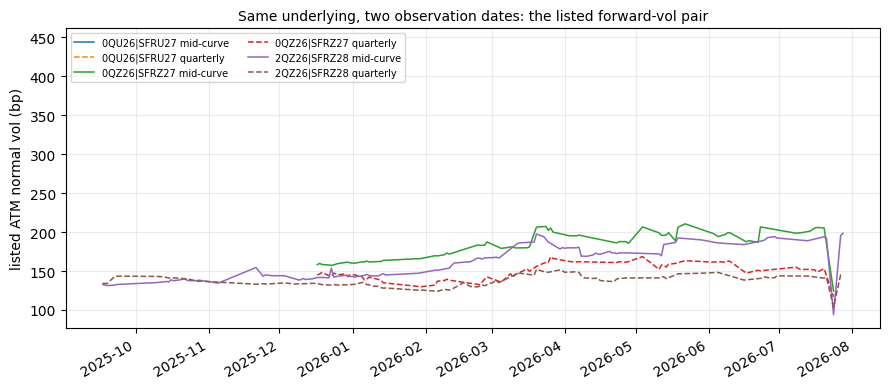

In [7]:
if len(fv):
    fig, ax = plt.subplots(figsize=(9, 4))
    for k, sub in fv.groupby("key"):
        s = sub.sort_values("as_of")
        ax.plot(s["as_of"], s["iv_mc_bp"], lw=1.1, label=f"{k} mid-curve")
        ax.plot(s["as_of"], s["iv_qtr_bp"], lw=1.1, ls="--", label=f"{k} quarterly")
    ax.set_ylabel("listed ATM normal vol (bp)")
    ax.set_title("Same underlying, two observation dates: the listed forward-vol "
                 "pair", fontsize=10)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.25)
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 9a. Mid-curve forward vol — grid ===
  108 configs | median -18.06bp | IQR [-129.13, +68.67] | 48% net-positive | best +262.93bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
     fade  10             60               1.0         z0         6     0.833      43.821       262.927      657318.50   4.982    -39.978
     fade   5             60               1.0        t10         9     0.667      27.051       243.459      608648.00   3.922    -45.324
     fade   5             60               1.0         z0         5     0.800      48.291       241.454      603635.00   3.555    -59.204
     fade   1             40               1.0        t10         9     0.667      20.065       180.583      451457.25   2.730    -83.055
     fade   1             60               1.0        t10         9     0.667      20.065       180.583   

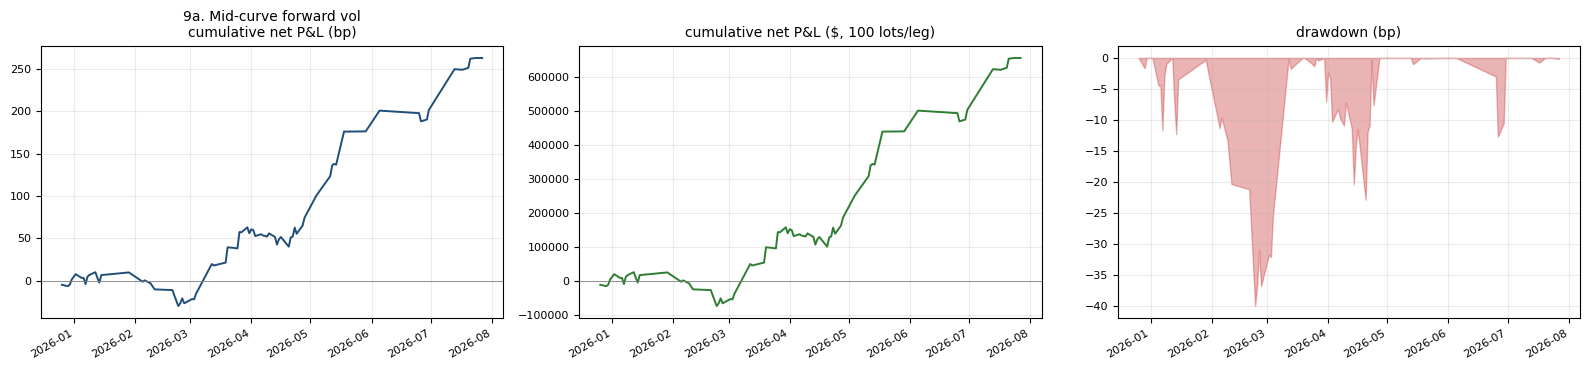


TRADE LOG (first rows)
         key  dir           structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp   net_bp   net_usd  stale_frac  pkg_contracts    exit_reason
2QZ26|SFRZ28    1 fwdvol 2QZ26|SFRZ28  2025-12-23 2025-12-24 2026-02-11    20 -1.016   -6.2561      4.0 -10.2561 -25640.32       0.000           5.51       max_hold
2QZ26|SFRZ28    1 fwdvol 2QZ26|SFRZ28  2026-02-13 2026-02-17 2026-04-06    20 -2.184   57.4055      4.0  53.4055 133513.81       0.000           5.73       max_hold
0QZ26|SFRZ27    1 fwdvol 0QZ26|SFRZ27  2026-03-20 2026-03-24 2026-05-11    12 -1.106   45.4828      4.0  41.4828 103706.97       0.043           5.09 mean_reversion
2QZ26|SFRZ28    1 fwdvol 2QZ26|SFRZ28  2026-04-07 2026-04-08 2026-06-05    20 -1.295  120.2213      4.0 116.2213 290553.14       0.000           5.99       max_hold
2QZ26|SFRZ28    1 fwdvol 2QZ26|SFRZ28  2026-06-16 2026-06-24 2026-07-27     9 -1.202   60.7882      4.0  56.7882 141970.54       0.045           6.61  

In [8]:
FV_IDX = fv.set_index(["key", "as_of"]).sort_index() if len(fv) else None


def builder_fwdvol(key, exec_date, direction):
    """Long the quarterly straddle, short the mid-curve straddle (vega-ratioed)."""
    try:
        r = FV_IDX.loc[(key, exec_date)]
    except (KeyError, AttributeError):
        return None
    if isinstance(r, pd.DataFrame):
        r = r.iloc[0]
    mcs, und = key.split("|")
    # vega of an ATM normal straddle scales with sqrt(T); ratio the near leg up
    ratio = float(np.sqrt(max(r["tte_qtr"], 1e-6) / max(r["tte_mc"], 1e-6)))
    ratio = float(np.clip(ratio, 0.25, 4.0))
    return Structure((
        Leg("option", und, 1.0, "C", float(r["k_q_c"])),
        Leg("option", und, 1.0, "P", float(r["k_q_p"])),
        Leg("option", mcs, -ratio, "C", float(r["k_mc_c"])),
        Leg("option", mcs, -ratio, "P", float(r["k_mc_p"])),
    ), label=f"fwdvol {key}")


BASE = LabConfig(lag=1, round_trip_cost_bp=CONFIG["cost_bp"],
                 contracts_per_leg=CONFIG["contracts_per_leg"],
                 delta_hedge="daily", future_leg_bp=0.25,
                 zscore_min_periods=CONFIG["zscore_min_periods"])
GRID = {"direction": list(CONFIG["directions"]), "ma": list(CONFIG["mas"]),
        "zscore_window": list(CONFIG["zscore_windows"]),
        "entry_min_zscore": list(CONFIG["entry_zs"]),
        "exit_style": list(CONFIG["exits"])}
PARAMS = ["direction", "ma", "zscore_window", "entry_min_zscore", "exit_style"]

if len(fv) > 40:
    sig_fv = fv.copy()
    sig_fv["signal"] = sig_fv["iv_spread_bp"]
    out_fv = run_framework(
        "9a. Mid-curve forward vol", signals=sig_fv, book=book,
        builder=builder_fwdvol, base=BASE, grid_spec=GRID, params=PARAMS, cls="B",
        note="quarterly straddle vs sqrt(T)-ratioed mid-curve straddle, "
             "same underlying, delta-hedged daily")
else:
    print("not enough forward-vol history to backtest")

## 9b — coupling digitals: the SAME strike on the SAME underlying, two expiries

This is the cleanest coupling object in the whole lab. Both digitals are
`P(the SFRZ27 rate >= K)`; the only difference is *when* it is observed. Their
spread is the listed price of "the rate gets there later rather than sooner" —
with no futures-spread level constraint contaminating it, because there is only
one future.

In [9]:
rows = []
for mcs, und in pairs:
    dates = sorted({t for (t, s) in QDAY if s == mcs}
                   & {t for (t, s) in QDAY if s == und})
    for ts in dates:
        gm = QDAY[(ts, mcs)]
        gq = QDAY[(ts, und)]
        gm = gm[gm["oi"] >= CONFIG["min_oi"]]
        gq = gq[gq["oi"] >= CONFIG["min_oi"]]
        f = FWD.get((ts, und))
        fp = FWD_PX.get((ts, und))
        if f is None or not np.isfinite(f) or gm.empty or gq.empty:
            continue
        # strikes drawn from the MID-CURVE's own ladder (nearest the forward and
        # its two neighbours) rather than forward +/- a fixed offset, which the
        # sparse mid-curve chain usually cannot supply
        ladder = np.sort(gm["strike_rate"].unique())
        if ladder.size < 3:
            continue
        c_idx = int(np.abs(ladder - float(f)).argmin())
        picks = [ladder[i] for i in (c_idx - 1, c_idx, c_idx + 1)
                 if 0 <= i < ladder.size]
        for o, k in zip((-1, 0, 1), picks):
            k = float(k)
            dm = vertical_digital(gm, k, tol=CONFIG["digital_tol"],
                                  forward_price=float(fp))
            dq = vertical_digital(gq, k, tol=CONFIG["digital_tol"],
                                  forward_price=float(fp))
            if dm is None or dq is None:
                continue
            if not (-0.02 <= dm["prob"] <= 1.02) or not (-0.02 <= dq["prob"] <= 1.02):
                continue
            rows.append({
                "as_of": ts, "key": f"{mcs}|{und}@{o:+.2f}", "mc": mcs, "qtr": und,
                "offset": o, "strike_rate": k,
                "moneyness_bp": (k - float(f)) * 100.0,
                "p_mc": dm["prob"], "p_qtr": dq["prob"],
                "signal": dq["prob"] - dm["prob"],
                "mc_lo": dm["k_lo"], "mc_hi": dm["k_hi"], "mc_r": dm["right"],
                "q_lo": dq["k_lo"], "q_hi": dq["k_hi"], "q_r": dq["right"],
                "gate": True})
cd = pd.DataFrame(rows)
print(f"coupling-digital panel: {len(cd)} rows, "
      f"{cd['key'].nunique() if len(cd) else 0} keys")
if len(cd):
    cd = add_event_distance(cd)
    print(cd.groupby("offset")[["p_mc", "p_qtr", "signal"]].describe()
          .round(3).to_string())

coupling-digital panel: 74 rows, 5 keys
        p_mc                                              p_qtr                                               signal                                              
       count   mean    std   min   25%   50%    75%   max count   mean    std    min   25%    50%   75%   max  count   mean    std   min   25%   50%    75%    max
offset                                                                                                                                                            
-1       1.0  0.520    NaN  0.52  0.52  0.52  0.520  0.52   1.0  0.500    NaN  0.500  0.50  0.500  0.50  0.50    1.0 -0.020    NaN -0.02 -0.02 -0.02 -0.020 -0.020
 0      72.0  0.009  0.055  0.00  0.00  0.00  0.005  0.46  72.0  0.022  0.053  0.005  0.01  0.015  0.02  0.44   72.0  0.013  0.009 -0.02  0.01  0.01  0.015  0.064
 1       1.0  0.420    NaN  0.42  0.42  0.42  0.420  0.42   1.0  0.410    NaN  0.410  0.41  0.410  0.41  0.41    1.0 -0.010    NaN -0.01 -0.01 -0

  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 9b. Mid-curve coupling digitals — grid ===
  108 configs | median -8.78bp | IQR [-13.34, -6.84] | 0% net-positive | best -3.09bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
     fade   5             60               2.0         z0         1       0.0      -3.085        -3.085       -7713.25  -2.696     -4.074
     fade   5             40               2.0         z0         1       0.0      -3.085        -3.085       -7713.25  -2.696     -4.074
     fade  10             60               2.0         z0         1       0.0      -3.132        -3.132       -7830.75  -2.513     -4.040
     fade  10             40               2.0         z0         1       0.0      -3.132        -3.132       -7830.75  -2.513     -4.040
     fade   1             60               1.5         z0         1       0.0      -3.186        -3.186   

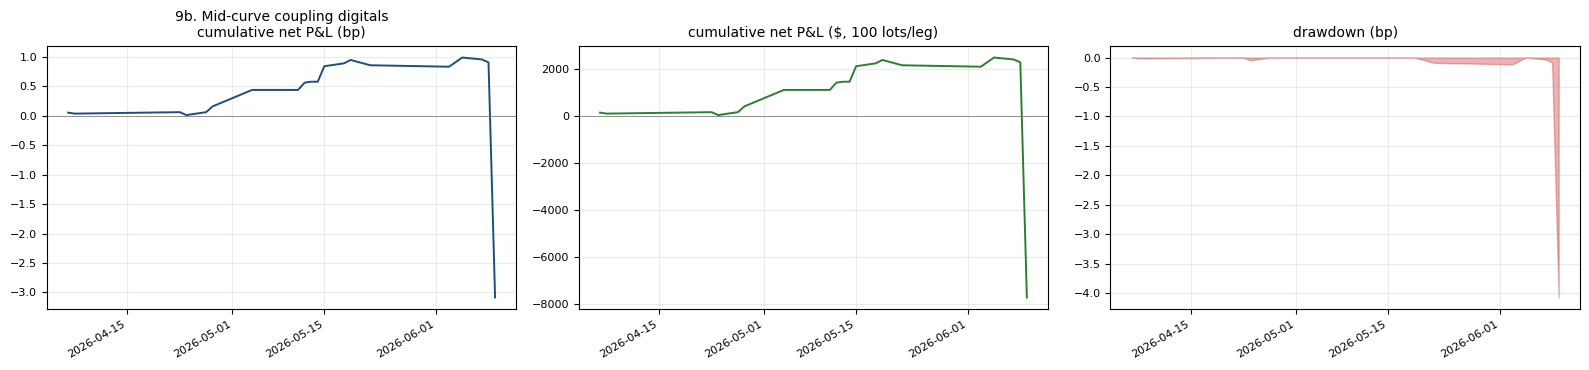


TRADE LOG (first rows)
               key  dir                  structure signal_date      entry       exit  days  z_in  gross_bp  cost_bp  net_bp  net_usd  stale_frac  pkg_contracts exit_reason
0QZ26|SFRZ27@+0.00   -1 coupdig 0QZ26|SFRZ27@+0.00  2026-03-27 2026-04-03 2026-06-10    20 2.071    0.9147      4.0 -3.0853 -7713.37       0.957            8.0    max_hold

EXIT COMPARISON
exit  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp  avg_hold_days
  z0         1       0.0      -3.085        -3.085       -7713.25  -2.696     -4.074           20.0
half         1       0.0      -3.085        -3.085       -7713.25  -2.696     -4.074           20.0
  t5         2       0.0      -4.193        -8.386      -20965.25  -7.972     -8.447            5.0
 t10         2       0.0      -3.700        -7.400      -18499.00  -4.318     -7.961           10.0
 t20         1       0.0      -3.085        -3.085       -7713.25  -2.696     -4.074           20.0

MARKS x LAG
si

In [10]:
CD_IDX = cd.set_index(["key", "as_of"]).sort_index() if len(cd) else None


def builder_coupling(key, exec_date, direction):
    try:
        r = CD_IDX.loc[(key, exec_date)]
    except (KeyError, AttributeError):
        return None
    if isinstance(r, pd.DataFrame):
        r = r.iloc[0]
    mcs, rest = key.split("|")
    und = rest.split("@")[0]
    return Structure(
        digital_legs(und, float(r["q_lo"]), float(r["q_hi"]), str(r["q_r"]), 1.0)
        + digital_legs(mcs, float(r["mc_lo"]), float(r["mc_hi"]), str(r["mc_r"]), -1.0),
        label=f"coupdig {key}")


if len(cd) > 40:
    out_cd = run_framework(
        "9b. Mid-curve coupling digitals", signals=cd, book=book,
        builder=builder_coupling, base=BASE, grid_spec=GRID, params=PARAMS,
        cls="B", note="same strike, same underlying, two expiries — "
                      "no futures-spread level constraint")
else:
    print("not enough coupling-digital history to backtest")

## 9c — skew term structure on one underlying

The risk reversal at the mid-curve expiry against the risk reversal at the
quarterly expiry: is the hike/cut asymmetry priced into the near observation
window or the far one?

skew-TS panel: 181 rows
              mc_rr                                                     q_rr                                                        signal                                         
              count    mean    std    min    25%    50%    75%    max  count    mean    std     min     25%     50%     75%     max  count  mean   std   min  25%   50%   75%   max
key                                                                                                                                                                                
0QU26|SFRU27    1.0 -425.00    NaN -425.0 -425.0 -425.0 -425.0 -425.0    1.0 -425.50    NaN -425.50 -425.50 -425.50 -425.50 -425.50    1.0 -0.50   NaN -0.50 -0.5 -0.50 -0.50 -0.50
0QZ26|SFRZ27   69.0 -373.29  33.39 -429.0 -400.0 -381.0 -331.0 -321.0   69.0 -374.82  32.83 -429.50 -401.00 -383.00 -333.00 -322.75   69.0 -1.53  0.71 -3.25 -2.0 -1.50 -1.00 -0.25
2QZ26|SFRZ28  111.0 -351.52  20.34 -379.5 -370.0 -351.5 -347.0 -297.0  111.0

  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 9c. Mid-curve skew term structure — grid ===
  108 configs | median -28.29bp | IQR [-75.66, +13.67] | 36% net-positive | best +104.90bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
 momentum   1             60               1.0         z0         8     0.500      13.112       104.899      262246.50   2.633    -32.805
 momentum   1             40               1.0         z0         8     0.500      13.112       104.899      262246.50   2.633    -32.805
 momentum   1             60               1.5         z0         6     0.667      17.401       104.407      261017.25   3.243    -32.805
 momentum   1             40               1.5         z0         6     0.500      15.843        95.060      237648.75   3.081    -32.805
 momentum   1             60               1.5         t5        10     0.600       8.162        81

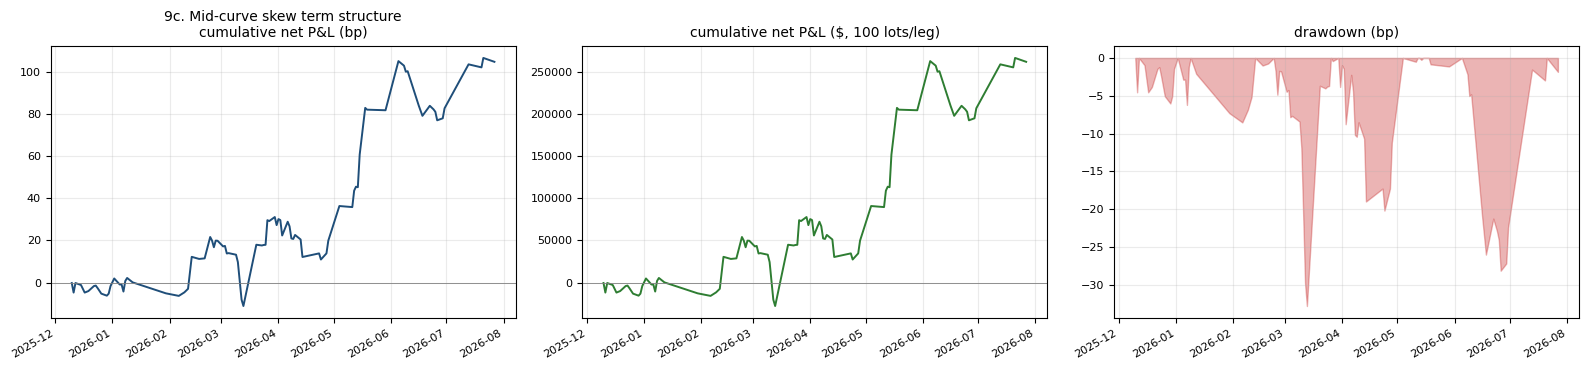


TRADE LOG (first rows)
         key  dir             structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp  net_bp   net_usd  stale_frac  pkg_contracts    exit_reason
2QZ26|SFRZ28   -1 mcskewTS 2QZ26|SFRZ28  2025-12-08 2025-12-09 2026-01-12    20 -1.200    4.0710      4.0  0.0710    177.58       0.000            4.0       max_hold
2QZ26|SFRZ28   -1 mcskewTS 2QZ26|SFRZ28  2026-01-15 2026-01-29 2026-01-30     1 -1.091   -1.2117      4.0 -5.2117 -13029.18       0.217            4.0 mean_reversion
2QZ26|SFRZ28    1 mcskewTS 2QZ26|SFRZ28  2026-01-30 2026-02-05 2026-03-13    15  1.740    2.1265      4.0 -1.8735  -4683.66       0.217            4.0 mean_reversion
0QZ26|SFRZ27    1 mcskewTS 0QZ26|SFRZ27  2026-02-24 2026-02-26 2026-03-10     4  2.028   -0.1590      4.0 -4.1590 -10397.55       0.043            4.0 mean_reversion
0QZ26|SFRZ27   -1 mcskewTS 0QZ26|SFRZ27  2026-03-16 2026-03-17 2026-05-19    20 -1.528   80.4492      4.0 76.4492 191122.96       0.043           

In [11]:
rows = []
for mcs, und in pairs:
    dates = sorted({t for (t, s) in QDAY if s == mcs}
                   & {t for (t, s) in QDAY if s == und})
    for ts in dates:
        gm = QDAY[(ts, mcs)][lambda d: d["oi"] >= CONFIG["min_oi"]]
        gq = QDAY[(ts, und)][lambda d: d["oi"] >= CONFIG["min_oi"]]
        f = FWD.get((ts, und))
        if f is None or not np.isfinite(f) or gm.empty or gq.empty:
            continue
        legs = {}
        ok = True
        ladder = np.sort(gm["strike_rate"].unique())
        if ladder.size < 3:
            continue
        hi_r, lo_r = float(ladder[-1]), float(ladder[0])   # widest available pair
        for tag, g in (("mc", gm), ("q", gq)):
            hk = pick_listed_strike(g, "P", hi_r, tol=0.02)
            ct = pick_listed_strike(g, "C", lo_r, tol=0.02)
            if hk is None or ct is None:
                ok = False
                break
            legs[f"{tag}_hk_K"] = float(hk["strike_price"])
            legs[f"{tag}_ct_K"] = float(ct["strike_price"])
            legs[f"{tag}_rr"] = float(hk["premium_bp"] - ct["premium_bp"])
        if not ok:
            continue
        rows.append({"as_of": ts, "key": f"{mcs}|{und}", "mc": mcs, "qtr": und,
                     "signal": legs["q_rr"] - legs["mc_rr"], "gate": True, **legs})
sk = pd.DataFrame(rows)
print(f"skew-TS panel: {len(sk)} rows")
if len(sk):
    sk = add_event_distance(sk)
    print(sk.groupby("key")[["mc_rr", "q_rr", "signal"]].describe()
          .round(2).to_string())

SK_IDX = sk.set_index(["key", "as_of"]).sort_index() if len(sk) else None


def builder_skewts(key, exec_date, direction):
    try:
        r = SK_IDX.loc[(key, exec_date)]
    except (KeyError, AttributeError):
        return None
    if isinstance(r, pd.DataFrame):
        r = r.iloc[0]
    mcs, und = key.split("|")
    return Structure((
        Leg("option", und, 1.0, "P", float(r["q_hk_K"])),
        Leg("option", und, -1.0, "C", float(r["q_ct_K"])),
        Leg("option", mcs, -1.0, "P", float(r["mc_hk_K"])),
        Leg("option", mcs, 1.0, "C", float(r["mc_ct_K"])),
    ), label=f"mcskewTS {key}")


if len(sk) > 40:
    out_sk = run_framework(
        "9c. Mid-curve skew term structure", signals=sk, book=book,
        builder=builder_skewts, base=BASE, grid_spec=GRID, params=PARAMS,
        cls="B", note="RR(quarterly expiry) - RR(mid-curve expiry), one underlying")
else:
    print("not enough skew-TS history to backtest")